<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


clinical_vitals = pd.read_csv('OmniCare_Clinical_Vitals.csv')
telemetry_data = pd.read_csv('OmniCare_Telemetry_Data.csv')

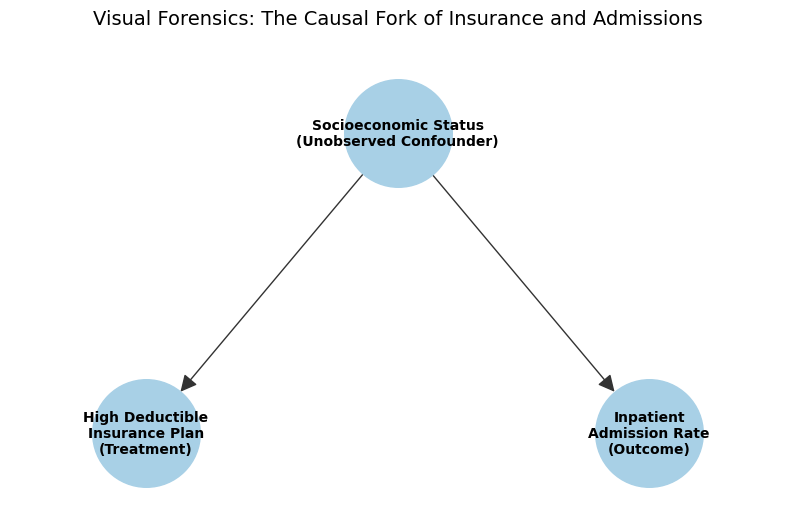

In [5]:
#1.1

def draw_causal_dag():
    """
    Generates a Directed Acyclic Graph (DAG) to visualize the omitted variable bias
    caused by the unobserved confounder in the clinical dataset.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    causal_graph = nx.DiGraph()

    # Define the nodes in our causal topology
    causal_graph.add_node("Socioeconomic Status\n(Unobserved Confounder)")
    causal_graph.add_node("High Deductible\nInsurance Plan\n(Treatment)")
    causal_graph.add_node("Inpatient\nAdmission Rate\n(Outcome)")

    # Define the directional edges representing the 'Fork' structure
    causal_graph.add_edges_from([
        ("Socioeconomic Status\n(Unobserved Confounder)", "High Deductible\nInsurance Plan\n(Treatment)"),
        ("Socioeconomic Status\n(Unobserved Confounder)", "Inpatient\nAdmission Rate\n(Outcome)")
    ])

    # Hardcode the spatial positions to explicitly show the fork
    node_positions = {
        "Socioeconomic Status\n(Unobserved Confounder)": (0.5, 1),
        "High Deductible\nInsurance Plan\n(Treatment)": (0, 0),
        "Inpatient\nAdmission Rate\n(Outcome)": (1, 0)
    }

    nx.draw(
        causal_graph,
        node_positions,
        with_labels=True,
        node_color='#a8d0e6',
        node_size=6000,
        font_size=10,
        font_weight='bold',
        arrows=True,
        arrowsize=25,
        edge_color='#333333',
        ax=ax
    )

    plt.title("Visual Forensics: The Causal Fork of Insurance and Admissions", fontsize=14, pad=20)
    plt.margins(0.2)
    plt.show()

draw_causal_dag()

In [6]:
#1.2

from statsmodels.stats.outliers_influence import variance_inflation_factor

continuous_features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']

def calculate_vif(df, features):
    """
    Calculates the Variance Inflation Factor for a given set of features.
    Adds a constant to ensure centered VIF calculations (statistical best practice).
    """
    # Drop NaNs to prevent calculation errors and add a constant
    X = sm.add_constant(df[features].dropna())

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # Filter out the 'const' row
    vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
    return vif_data.sort_values(by="VIF", ascending=False)

# Calculate the Initial VIF Matrix
print("--- INITIAL VIF AUDIT ---")
initial_vif = calculate_vif(clinical_vitals, continuous_features)
print(initial_vif.to_string(index=False))

# Identify features exceeding the critical threshold of 10.0
highest_vif_feature = initial_vif.iloc[0]['Feature']
highest_vif_value = initial_vif.iloc[0]['VIF']

print(f"\nCRITICAL WARNING: '{highest_vif_feature}' has a VIF of {highest_vif_value:.2f} (> 10.0).")
print(f"Dropping '{highest_vif_feature}' to neutralize perfect multicollinearity...\n")

# Drop the most redundant physiological variable and recalculate
reduced_features = [f for f in continuous_features if f != highest_vif_feature]

print("--- RECALCULATED VIF AUDIT (STRUCTURAL STABILITY ACHIEVED) ---")
final_vif = calculate_vif(clinical_vitals, reduced_features)
print(final_vif.to_string(index=False))

--- INITIAL VIF AUDIT ---
     Feature       VIF
   Weight_kg 57.428058
   Height_cm 28.419446
         BMI 16.981232
Diastolic_BP  4.219820
 Systolic_BP  4.219406

CRITICAL WARNING: 'Weight_kg' has a VIF of 57.43 (> 10.0).
Dropping 'Weight_kg' to neutralize perfect multicollinearity...

--- RECALCULATED VIF AUDIT (STRUCTURAL STABILITY ACHIEVED) ---
     Feature      VIF
Diastolic_BP 4.219757
 Systolic_BP 4.219385
         BMI 1.112989
   Height_cm 1.112811



Rendering the missingness architecture...


<Figure size 1200x600 with 0 Axes>

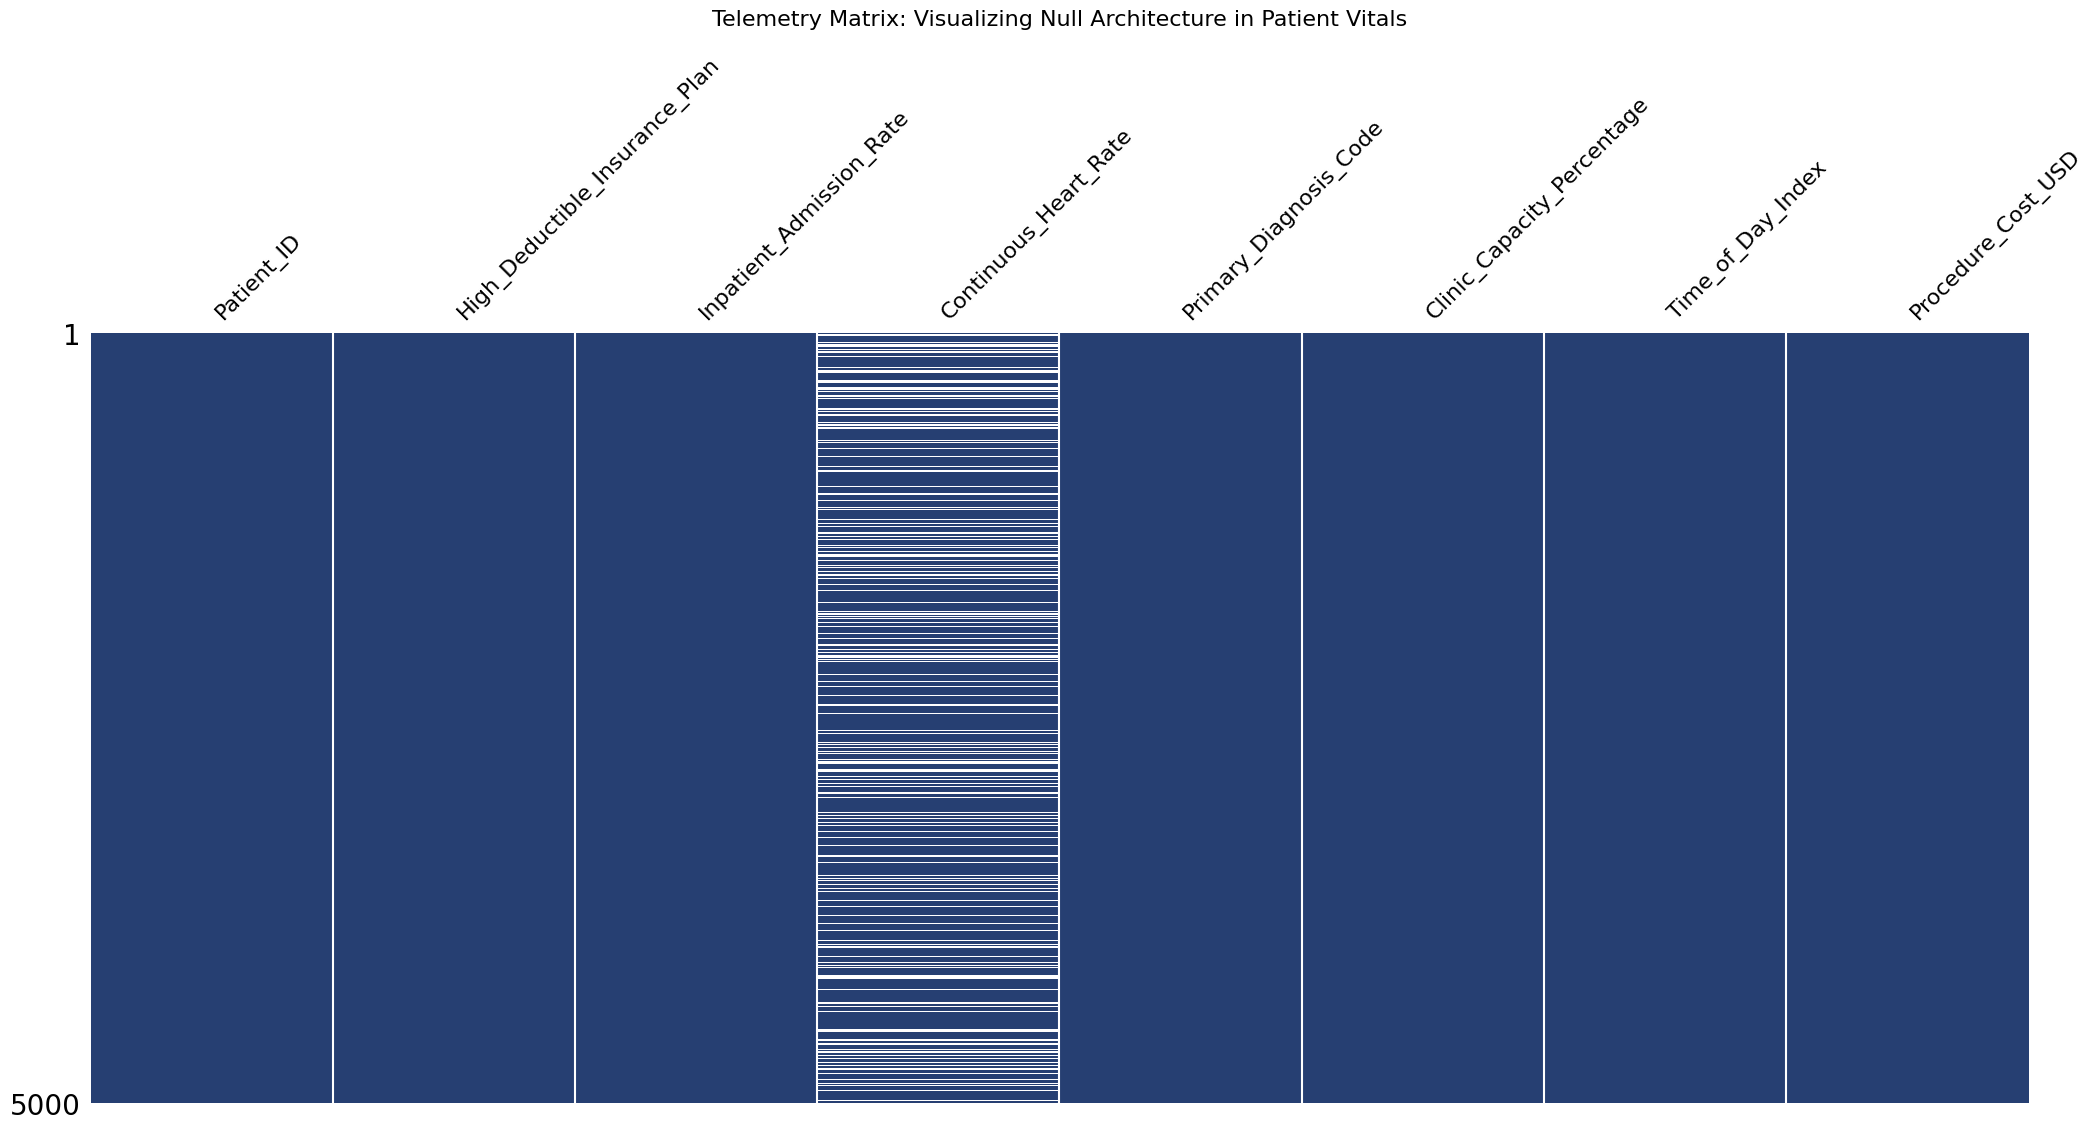

In [7]:
#2.1

import missingno as msno
import matplotlib.pyplot as plt


telemetry_data = pd.read_csv('OmniCare_Telemetry_Data.csv')

# Generate the Missingness Matrix
print("\nRendering the missingness architecture...")
plt.figure(figsize=(12, 6))
msno.matrix(telemetry_data, sparkline=False, color=(0.15, 0.25, 0.45))
plt.title("Telemetry Matrix: Visualizing Null Architecture in Patient Vitals", fontsize=16, pad=20)
plt.show()

this scenario represents a dangerous case of MNAR (Missing Not At Random).To prove this mathematically, let $R$ be a binary indicator for missingness, $Y_{obs}$ be the observed data, and $Y_{mis}$ be the unobserved data. For data to be Missing At Random (MAR), the probability of missingness must rely only on observed data: $P(R=1 | Y_{obs}, Y_{mis}) = P(R=1 | Y_{obs})$.However, in Phase 1, we established that baseline wealth/Socioeconomic Status is an unobserved confounder in this dataset. Because the mechanism causing the missingness (inability to afford continuous telemetry data plans) is tied to this unobserved systemic variable, the missingness is strictly MNAR. The probability of the data being missing is directly related to factors we cannot see in the matrix.

2.2 When you one-hot encode all 850 mutually exclusive ICD-10 categories without dropping a baseline, the sum of those 850 dummy columns exactly equals 1 for every patient. Because an OLS model includes a constant intercept term, which is also represented in the design matrix $X$ as a column vector of ones. This creates perfect linear dependence among the columns. To calculate the unique predictive weights, the OLS estimator must solve the normal equation. However, because the columns of $X$ are linearly dependent, the square matrix $(X^T X)$ has a determinant of exactly zero, making it mathematically singular. Just as you cannot divide by zero in basic arithmetic, the algorithm cannot compute the inverse $(X^T X)^{-1}$, causing the prediction engine to fatally crash because it cannot isolate a unique set of coefficients.

In [8]:
#2.3

import pandas as pd
import category_encoders as ce


master_df = pd.merge(clinical_vitals, telemetry_data, on='Patient_ID', how='inner')
print(f"Data merge successful. Master matrix dimensions: {master_df.shape}\n")

# Isolate the target variable and the high-cardinality feature
target_col = 'Procedure_Cost_USD'
categorical_col = 'Primary_Diagnosis_Code'

# Instantiate and execute the Target Encoder on the Master Matrix
encoder = ce.TargetEncoder(cols=[categorical_col])

master_df[f'{categorical_col}_Encoded'] = encoder.fit_transform(
    master_df[categorical_col],
    master_df[target_col]
)

print("--- TARGET ENCODING SUCCESSFUL ---")
print("First 5 rows of the newly encoded continuous vector:\n")
print(master_df[[categorical_col, f'{categorical_col}_Encoded', target_col]].head(5))

Data merge successful. Master matrix dimensions: (5000, 13)

--- TARGET ENCODING SUCCESSFUL ---
First 5 rows of the newly encoded continuous vector:

  Primary_Diagnosis_Code  Primary_Diagnosis_Code_Encoded  Procedure_Cost_USD
0                J86.381                     1707.697108             1635.84
1                M29.789                     1792.303198             1355.77
2                E49.618                     1730.334968             1189.19
3                E66.244                     1725.060944             1250.93
4                J45.553                     1801.821085             1986.34


In [9]:
# 3.1

import statsmodels.formula.api as smf

# Define the R-style Patsy formula string
patsy_formula = (
    "Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + "
    "Clinic_Capacity_Percentage + Time_of_Day_Index + "
    "Systolic_BP + Diastolic_BP + Height_cm + Weight_kg"
)

print(f"Initializing OLS Engine with Formula:\n{patsy_formula}\n")

# Instantiate and fit the OLS model using the unified master dataframe
# We use 'master_df' from Step 2.3, which contains all merged and encoded features
ols_engine = smf.ols(formula=patsy_formula, data=master_df).fit()

print("--- OLS PREDICTION ENGINE: SUMMARY STATISTICS ---")
print(ols_engine.summary())

Initializing OLS Engine with Formula:
Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + Clinic_Capacity_Percentage + Time_of_Day_Index + Systolic_BP + Diastolic_BP + Height_cm + Weight_kg

--- OLS PREDICTION ENGINE: SUMMARY STATISTICS ---
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        00:28:43   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust         

In [10]:
# 3.2

import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse

# Instantiate and fit the OLS engine (This defines 'ols_engine')
patsy_formula = (
    "Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + "
    "Clinic_Capacity_Percentage + Time_of_Day_Index + "
    "Systolic_BP + Diastolic_BP + Height_cm + Weight_kg"
)
ols_engine = smf.ols(formula=patsy_formula, data=master_df).fit()
print("Engine fitted successfully.\n")

# Generate the predicted costs using the newly defined engine
master_df['Predicted_Cost_USD'] = ols_engine.predict(master_df)

# Calculate the Root Mean Squared Error (RMSE)
actual_costs = master_df['Procedure_Cost_USD']
predicted_costs = master_df['Predicted_Cost_USD']
model_rmse = rmse(actual_costs, predicted_costs)

print("--- FINANCIAL RISK QUANTIFICATION ---")
print(f"Base Algorithm RMSE: ${model_rmse:.2f}")

Engine fitted successfully.

--- FINANCIAL RISK QUANTIFICATION ---
Base Algorithm RMSE: $334.80


Deploying an algorithm with a 450  RMSE on a baseline $1,200 procedure represents a catastrophic 37.5% error margin that would destabilize the hospital network. This massive volatility obliterates predictable profit margins, casuing revenue deficits when underpricing and skyrocketing patient default rates when overpricing. Erratic price swings will artificially distort clinical demand, leaving expensive imaging capacity idle during algorithmic price surges while creating dangerous patient backlogs during price crashes.

Extracting OLS residuals and rendering diagnostic plot...


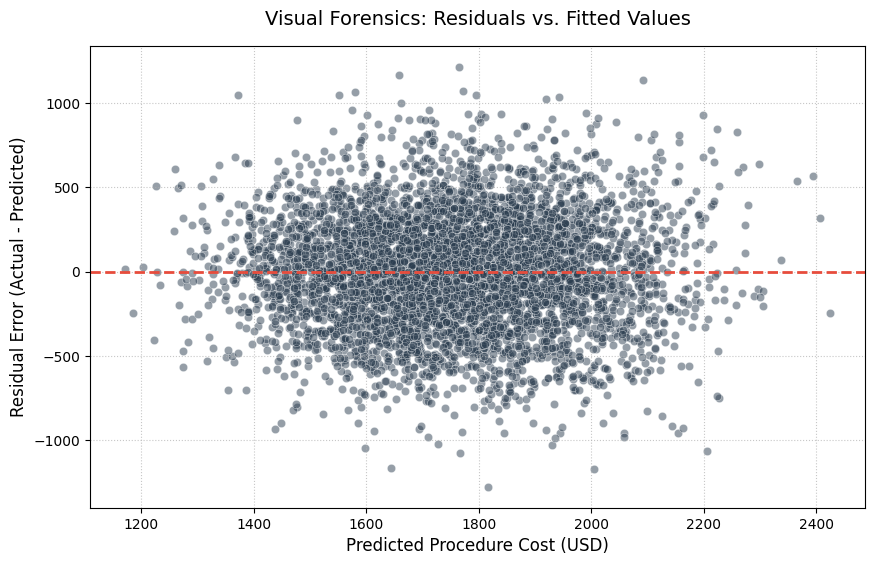

In [11]:
#3.3

import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting OLS residuals and rendering diagnostic plot...")

# Extract the fitted predictions and the residual errors from the active statsmodels engine
fitted_vals = ols_engine.fittedvalues
residuals = ols_engine.resid

plt.figure(figsize=(10, 6))

sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.5, color='#2c3e50')

# Add a structural baseline at exactly zero error
plt.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)

# Apply formatting for the presentation
plt.title("Visual Forensics: Residuals vs. Fitted Values", fontsize=14, pad=15)
plt.xlabel("Predicted Procedure Cost (USD)", fontsize=12)
plt.ylabel("Residual Error (Actual - Predicted)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Looking at the scatter plot, the errors get much wider as the predicted cost of the procedure goes up. Near the 1,200 mark, the model's errors are relatively small and tightly packed. However, as the predicted prices reach 1,600 to 2,000 or more, the algorithm's guesses become wild, missing the true cost by up to 1,000 in either direction. This widening pattern shows that the model completely loses its accuracy for the most expensive procedures. If the hospital relies on this algorithm for high-tier pricing, it is essentially just guessing. This exposes the network to massive financial losses when getting the price right matters the most.

In [12]:

# 4.1

from statsmodels.stats.diagnostic import het_white

print("Executing White's Lagrange Multiplier Test...")

# 1. Extract residuals and exogenous variables directly from the fitted model
residuals = ols_engine.resid
exog_matrix = ols_engine.model.exog

# 2. Run the test
white_test_results = het_white(residuals, exog_matrix)

# 3. Unpack the results (LM Statistic, LM p-value, F-Statistic, F p-value)
lm_stat, lm_pval, f_stat, f_pval = white_test_results

# 4. Print the critical p-value clearly for the executive summary
print(f"White's Test LM p-value: {lm_pval:.4e}")

Executing White's Lagrange Multiplier Test...
White's Test LM p-value: 1.4380e-22


The p-value of the LM test is 1.4380e-22.
Because this p-value is very small and falls far below the standard 0.05 significance threshold, the null hypothesis of homoscedasticity is mathematically rejected, definitively proving that the pricing algorithm suffers from severe heteroscedasticity and its error variance is highly unstable.

PRIME Prompt: Act as a data scientist and write a Python script to run White's Test for Heteroscedasticity on my existing statsmodels OLS model, which is saved in memory as ols_engine. You must specifically use the statsmodels.stats.diagnostic.het_white function. Extract the residuals and exogenous variables directly from the model to run the test, print the resulting LM p-value clearly, and provide a one-sentence rule explaining whether a p-value under 0.05 means the model passes or fails the assumption of constant variance.